# Clustering Method Evaluation: K-Means vs DBSCAN

Evaluates two clustering algorithms on the **root-node package features** extracted
from the dependency-graph dataset, after PCA dimensionality reduction.

| Section | What it does |
|---|---|
| 1 | Load data, standardise, PCA (95% variance) |
| 2 | PCA 2-D and UMAP 2-D scatter visualisation |
| 3 | Covariance eigenvalue ratio per cluster |
| 4a | K-Means (elbow method) |
| 4b | DBSCAN (k-NN eps guide + grid search) |
| 5 | Top-K Recall / Precision / F1 comparison |

## Setup

In [4]:
import os
import sys
import pickle
import random
import colorsys

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from umap import UMAP

%matplotlib inline

GRAPH_CACHE   = '../data/gnn_graph_dataset.pkl'
OUT_DIR       = '../models/lib/eval'
TRAIN_RATIO   = 0.8
TOP_K_PCT     = 0.33
VAR_THRESHOLD = 0.95
RANDOM_SEED   = 42

os.makedirs(OUT_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## Helper functions

In [ ]:
def top_k_metrics(results_df, cluster_col, top_k_pct, exclude_noise=False):
    """Recall / Precision / F1 for the smallest set of highest-risk clusters
    that covers ~top_k_pct of all packages (package-level Top-K, not cluster-level)."""
    df = results_df.copy()
    if exclude_noise:
        df = df[df[cluster_col] != -1]

    cluster_stats = (
        df.groupby(cluster_col)['label']
        .agg(n_vulnerable='sum', cluster_size='count')
        .assign(risk_score=lambda x: x['n_vulnerable'] / x['cluster_size'])
        .sort_values('risk_score', ascending=False)
        .reset_index()
    )

    # Add clusters in decreasing risk order until ~top_k_pct of packages are flagged
    n_top_pkgs = max(1, round(len(df) * top_k_pct))
    top_ids  = set()
    n_flagged = 0
    for _, row in cluster_stats.iterrows():
        top_ids.add(row[cluster_col])
        n_flagged += int(row['cluster_size'])
        if n_flagged >= n_top_pkgs:
            break

    total_vuln = (df['label'] == 1).sum()
    in_top     = df[cluster_col].isin(top_ids)
    true_pos   = ((df['label'] == 1) & in_top).sum()
    top_size   = in_top.sum()

    recall    = true_pos / total_vuln if total_vuln else 0.0
    precision = true_pos / top_size   if top_size   else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) else 0.0)
    return recall, precision, f1, cluster_stats, n_flagged


def scatter_2d(coords, labels, cluster_labels, title, path=None):
    """Side-by-side scatter: ground truth (left) vs cluster assignment (right)."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    gt_colors = ['#4878cf' if l == 0 else '#d65f5f' for l in labels]

    unique_cl = sorted(set(cluster_labels) - {-1})
    palette   = {c: colorsys.hsv_to_rgb(i / max(len(unique_cl), 1), 0.7, 0.85) + (1.0,)
                 for i, c in enumerate(unique_cl)}
    palette[-1] = (0.5, 0.5, 0.5, 0.5)   # noise = grey
    cl_colors = [palette[c] for c in cluster_labels]

    for ax, colors, subtitle in zip(
        axes,
        [gt_colors, cl_colors],
        ['Ground Truth  (blue=safe, red=vuln)', 'Cluster Assignment'],
    ):
        ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=6, alpha=0.5)
        ax.set_title(subtitle, fontsize=11)
        ax.axis('off')

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=120)
    plt.show()


def eigenvalue_analysis(X_pca, cluster_labels, method_name):
    """Per-cluster covariance eigenvalue ratio (high = elongated / non-spherical)."""
    rows = []
    for c in sorted(set(cluster_labels)):
        Xc = X_pca[cluster_labels == c]
        if Xc.shape[0] < 2:
            rows.append({'cluster': c, 'size': len(Xc),
                         'eig_max': float('nan'), 'eig_min': float('nan'), 'eig_ratio': float('nan')})
            continue
        eigs = np.linalg.eigvalsh(np.cov(Xc.T))
        eigs = eigs[eigs > 1e-10]
        if len(eigs) == 0:
            rows.append({'cluster': c, 'size': len(Xc),
                         'eig_max': float('nan'), 'eig_min': float('nan'), 'eig_ratio': float('nan')})
            continue
        rows.append({
            'cluster'  : c,
            'size'     : len(Xc),
            'eig_max'  : eigs.max(),
            'eig_min'  : eigs.min(),
            'eig_ratio': eigs.max() / eigs.min(),
        })
    df = pd.DataFrame(rows)
    print(f'[{method_name}] Eigenvalue ratio per cluster (higher = more elongated):')
    display(df.style.format({'eig_max': '{:.2f}', 'eig_min': '{:.2f}',
                             'eig_ratio': '{:.1f}'}).background_gradient(
        subset=['eig_ratio'], cmap='YlOrRd'))
    return df

## Step 1 — Load data, standardise, PCA

In [6]:
with open(GRAPH_CACHE, 'rb') as f:
    graph_dataset = pickle.load(f)

graph_dataset = [d for d in graph_dataset if d['data'].x.size(0) > 0]
n_vuln = sum(1 for d in graph_dataset if d['label'] == 1)
print(f'Loaded {len(graph_dataset)} graphs  ({n_vuln} vulnerable)')

features, labels_all, pkg_ids = [], [], []
for item in tqdm(graph_dataset, desc='Extracting root features'):
    features.append(item['data'].x[0].numpy())
    labels_all.append(item['label'])
    pkg_ids.append(item['pkg_id'])

X_raw      = np.array(features)
labels_all = np.array(labels_all)
print(f'Feature matrix: {X_raw.shape}')

Loaded 9668 graphs  (4823 vulnerable)


Extracting root features: 100%|██████████| 9668/9668 [00:00<00:00, 558485.72it/s]

Feature matrix: (9668, 27)


Train=7734  Test=1934
Vulnerable in test: 989 / 1934

PCA: 20 components → 95.3% variance retained


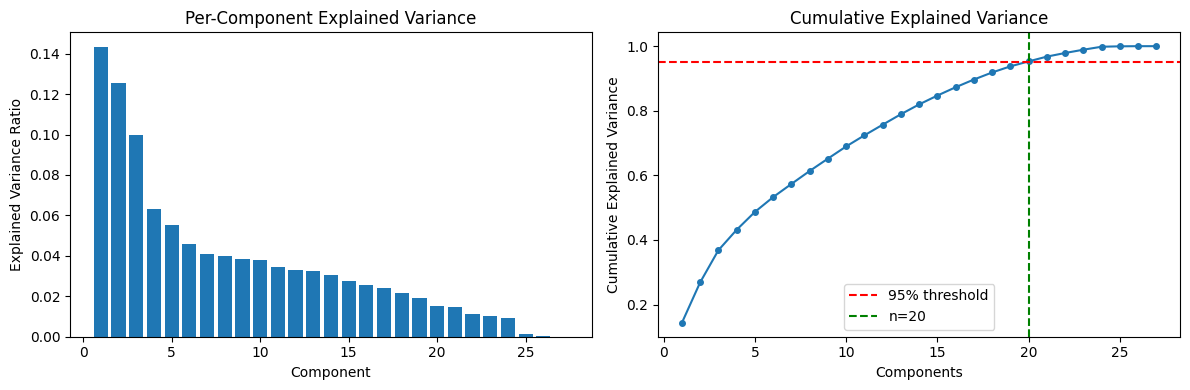

In [7]:
# Train / test split (same seed as GNN notebook)
indices = list(range(len(graph_dataset)))
random.seed(RANDOM_SEED)
random.shuffle(indices)
split       = int(len(indices) * TRAIN_RATIO)
train_idx   = indices[:split]
test_idx    = indices[split:]

X_train     = X_raw[train_idx]
X_test      = X_raw[test_idx]
test_labels = labels_all[test_idx]
test_pkgids = [pkg_ids[i] for i in test_idx]

print(f'Train={len(X_train)}  Test={len(X_test)}')
print(f'Vulnerable in test: {test_labels.sum()} / {len(test_labels)}')

# Standardise (fit on train only)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# PCA — choose n_components by cumulative explained variance (fit on train)
pca_full = PCA(random_state=RANDOM_SEED).fit(X_train_sc)
cum_var      = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.searchsorted(cum_var, VAR_THRESHOLD) + 1)
print(f'\nPCA: {n_components} components → {cum_var[n_components-1]*100:.1f}% variance retained')

# Explained variance plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_)
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Per-Component Explained Variance')

axes[1].plot(range(1, len(cum_var) + 1), cum_var, marker='o', markersize=4)
axes[1].axhline(VAR_THRESHOLD, color='red', linestyle='--',
                label=f'{VAR_THRESHOLD*100:.0f}% threshold')
axes[1].axvline(n_components, color='green', linestyle='--', label=f'n={n_components}')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance'); axes[1].legend()
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/pca_variance.png', dpi=120); plt.show()

pca         = PCA(n_components=n_components, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

## Step 2 — Visualisation: PCA 2-D and UMAP 2-D

Both projections show **ground truth labels only** here.  
After clustering (Steps 4a/4b) the same plots are re-drawn with cluster colours.

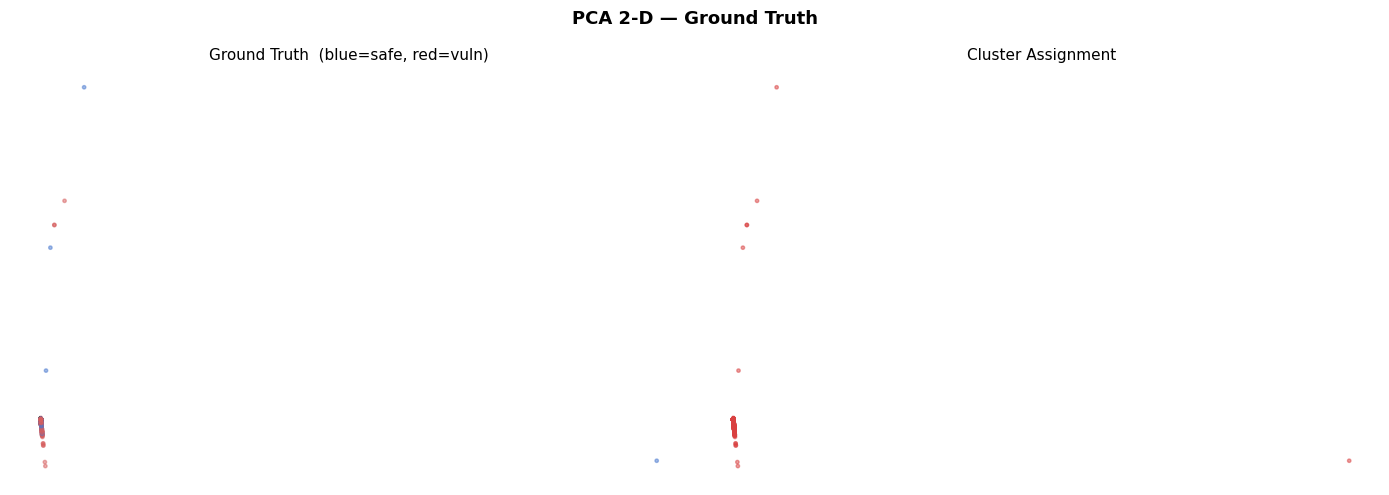

In [8]:
# PCA 2-D — fit directly on scaled test set for visualisation
pca2        = PCA(n_components=2, random_state=RANDOM_SEED)
X_test_pca2 = pca2.fit_transform(X_test_sc)

_dummy = np.zeros(len(X_test_pca2), dtype=int)   # placeholder clusters
scatter_2d(X_test_pca2, test_labels, _dummy,
           'PCA 2-D — Ground Truth',
           f'{OUT_DIR}/viz_pca2d_groundtruth.png')

/Users/xipingye/software-supply-chain-risk-detector/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


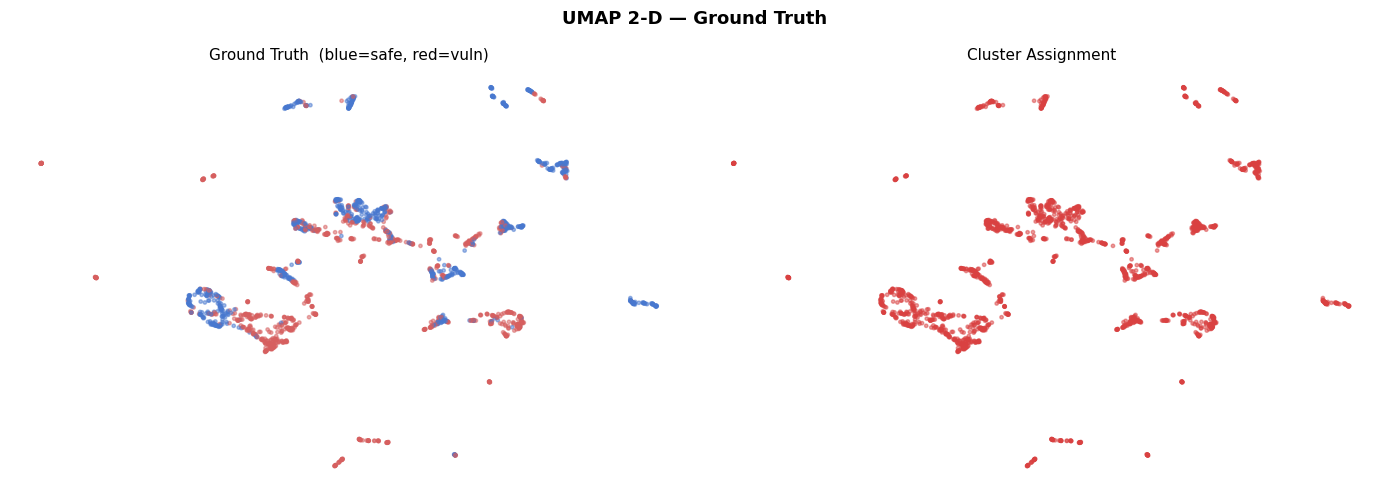

In [9]:
# UMAP — project PCA-reduced (n_components) features into 2-D
reducer     = UMAP(n_components=2, random_state=RANDOM_SEED,
                   n_neighbors=15, min_dist=0.1)
X_test_umap = reducer.fit_transform(X_test_pca)

scatter_2d(X_test_umap, test_labels, _dummy,
           'UMAP 2-D — Ground Truth',
           f'{OUT_DIR}/viz_umap2d_groundtruth.png')

## Step 4a — K-Means (elbow method)

Elbow sweep: 100%|██████████| 19/19 [00:00<00:00, 26.68it/s]


,K,Inertia,Delta,Delta2
0,2,81376.078125,NaN,NaN
1,3,48872.394531,32503.683594,NaN
2,4,44125.039062,4747.355469,27756.328125
3,5,40028.968750,4096.070312,651.285156
4,6,37131.179688,2897.789062,1198.281250
5,7,34763.210938,2367.968750,529.820312
6,8,32605.687500,2157.523438,210.445312
7,9,30718.757812,1886.929688,270.593750
8,10,29560.398438,1158.359375,728.570312
9,11,28019.054688,1541.343750,382.984375


Auto-detected elbow K = 4


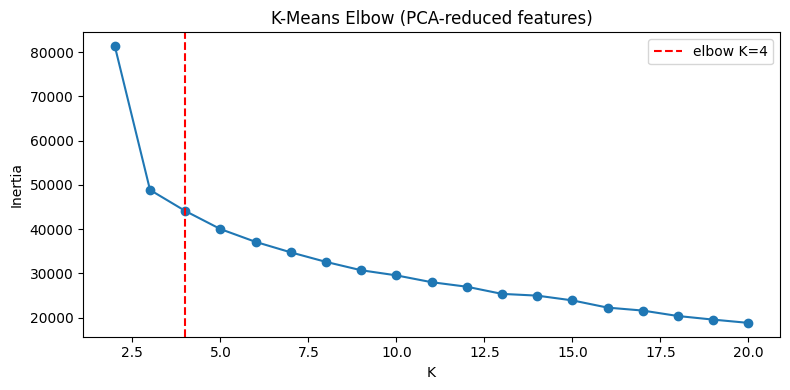

In [10]:
inertias = {}
for k in tqdm(range(2, 21), desc='Elbow sweep'):
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    km.fit(X_test_pca)
    inertias[k] = km.inertia_

elbow_df = pd.DataFrame({'K': list(inertias), 'Inertia': list(inertias.values())})
elbow_df['Delta']  = elbow_df['Inertia'].diff().abs()
elbow_df['Delta2'] = elbow_df['Delta'].diff().abs()
display(elbow_df)

best_k = int(elbow_df.loc[elbow_df['Delta2'].idxmax(), 'K'])
print(f'Auto-detected elbow K = {best_k}')

plt.figure(figsize=(8, 4))
plt.plot(elbow_df['K'], elbow_df['Inertia'], marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'elbow K={best_k}')
plt.xlabel('K'); plt.ylabel('Inertia')
plt.title('K-Means Elbow (PCA-reduced features)')
plt.legend(); plt.tight_layout()
plt.savefig(f'{OUT_DIR}/kmeans_elbow.png', dpi=120); plt.show()

In [11]:
# Override best_k if needed:
# best_k = 10

km_final    = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10)
km_clusters = km_final.fit_predict(X_test_pca)

km_df = pd.DataFrame({'pkg_id': test_pkgids, 'label': test_labels,
                      'cluster': km_clusters})
print(f'K-Means K={best_k}  |  cluster sizes:')
display(km_df.groupby('cluster')['label']
        .agg(n_vulnerable='sum', cluster_size='count')
        .assign(risk_score=lambda df: df['n_vulnerable']/df['cluster_size']))

K-Means K=4  |  cluster sizes:


,n_vulnerable,cluster_size,risk_score
cluster,,,
0,832,1738,0.478711
1,0,1,0.000000
2,3,5,0.600000
3,154,190,0.810526


### Step 3a — Eigenvalue analysis: K-Means clusters

In [12]:
km_eig_df = eigenvalue_analysis(X_test_pca, km_clusters, 'K-Means')
km_eig_df.to_csv(f'{OUT_DIR}/kmeans_eigenvalue_analysis.csv', index=False)

[K-Means] Eigenvalue ratio per cluster (higher = more elongated):


,cluster,size,eig_max,eig_min,eig_ratio
0,0,1738,3.23,0.00,46219.6
1,1,1,nan,nan,nan
2,2,5,807.66,0.00,7621317251809.5
3,3,190,12.66,0.00,500955.8


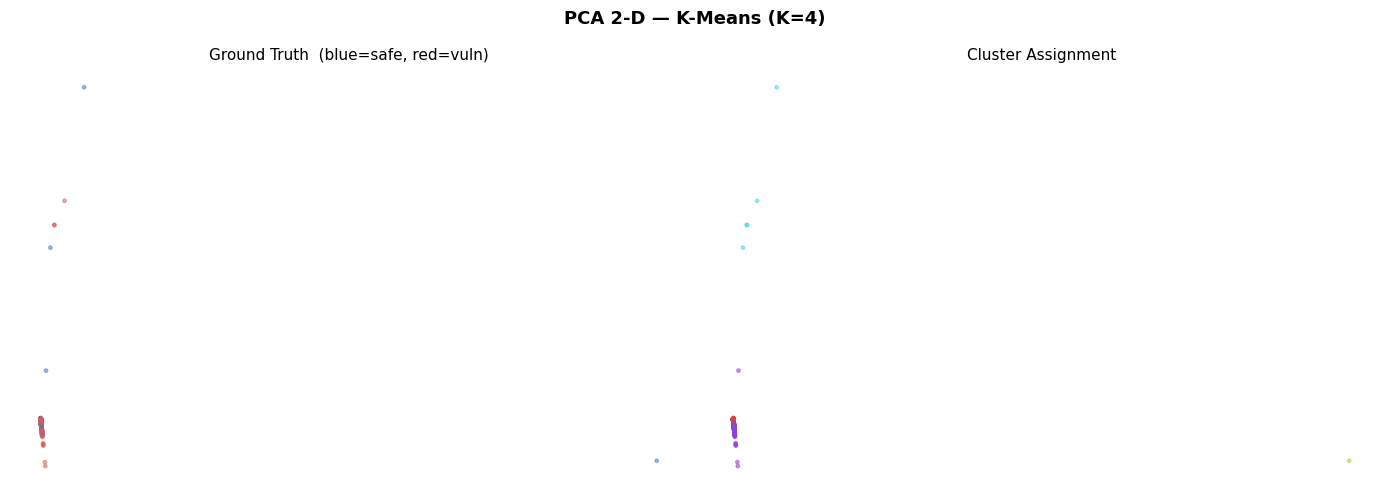

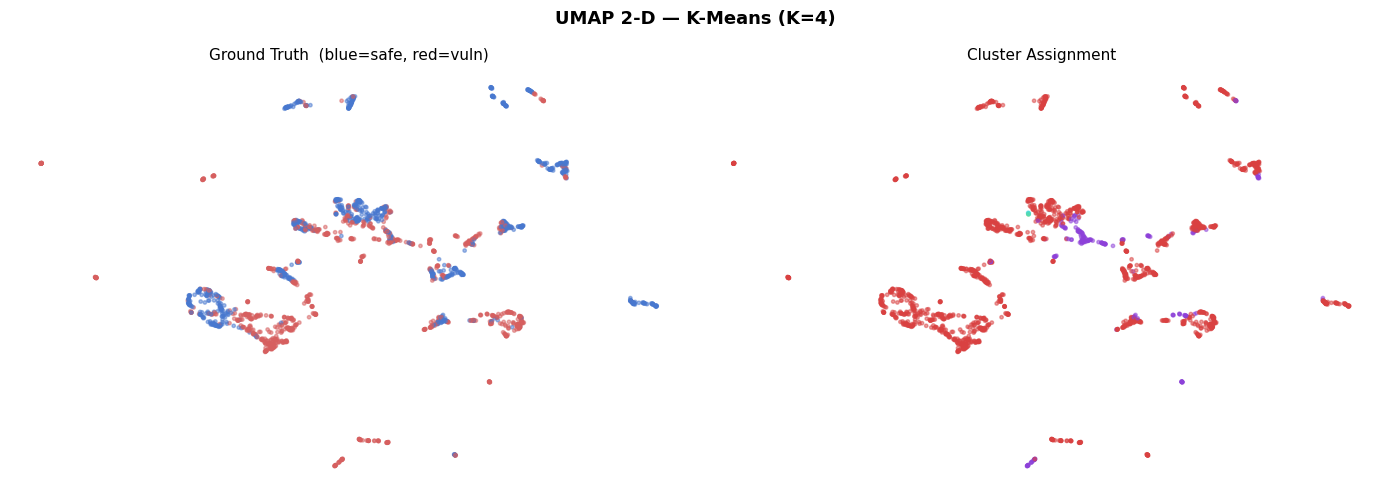

In [13]:
scatter_2d(X_test_pca2, test_labels, km_clusters,
           f'PCA 2-D — K-Means (K={best_k})',
           f'{OUT_DIR}/viz_pca2d_kmeans.png')
scatter_2d(X_test_umap, test_labels, km_clusters,
           f'UMAP 2-D — K-Means (K={best_k})',
           f'{OUT_DIR}/viz_umap2d_kmeans.png')

## Step 4b — DBSCAN (k-NN distance guide + grid search)

The k-NN distance plot shows where density drops sharply — that inflection point
gives a sensible `eps` range for the grid search.

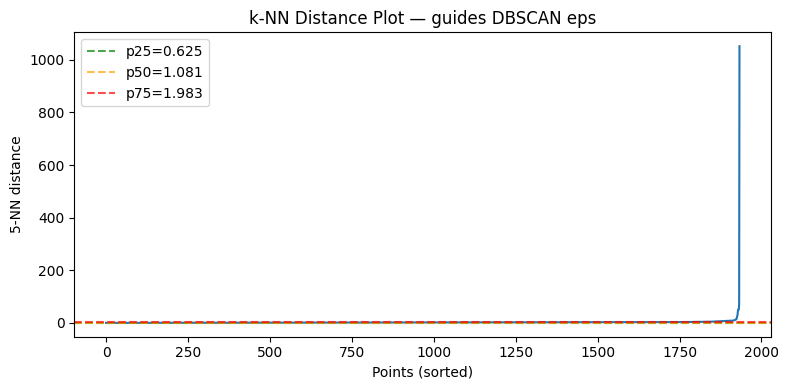

eps grid        : [0.625 0.896 1.168 1.44  1.711 1.983]
min_samples grid: [3, 5, 10, 20]


In [14]:
nn = NearestNeighbors(n_neighbors=5).fit(X_test_pca)
dists, _ = nn.kneighbors(X_test_pca)
knn_dists = np.sort(dists[:, -1])

p25, p50, p75 = np.percentile(knn_dists, [25, 50, 75])

plt.figure(figsize=(8, 4))
plt.plot(knn_dists)
plt.axhline(p25, color='green',  linestyle='--', alpha=0.7, label=f'p25={p25:.3f}')
plt.axhline(p50, color='orange', linestyle='--', alpha=0.7, label=f'p50={p50:.3f}')
plt.axhline(p75, color='red',    linestyle='--', alpha=0.7, label=f'p75={p75:.3f}')
plt.xlabel('Points (sorted)'); plt.ylabel('5-NN distance')
plt.title('k-NN Distance Plot — guides DBSCAN eps')
plt.legend(); plt.tight_layout()
plt.savefig(f'{OUT_DIR}/dbscan_knn_distance.png', dpi=120); plt.show()

EPS_GRID         = np.round(np.linspace(p25, p75, 6), 3)
MIN_SAMPLES_GRID = [3, 5, 10, 20]
print(f'eps grid        : {EPS_GRID}')
print(f'min_samples grid: {MIN_SAMPLES_GRID}')

In [15]:
dbscan_results = []
for eps in tqdm(EPS_GRID, desc='eps'):
    for ms in MIN_SAMPLES_GRID:
        cl     = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_test_pca)
        n_cl   = len(set(cl) - {-1})
        if n_cl == 0:
            continue
        n_noise = (cl == -1).sum()
        tmp_df  = pd.DataFrame({'label': test_labels, 'cluster': cl})
        rec, prec, f1, _, _ = top_k_metrics(tmp_df, 'cluster', TOP_K_PCT,
                                             exclude_noise=True)
        dbscan_results.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_cl, 'n_noise': n_noise,
            'noise_pct': round(n_noise / len(cl) * 100, 1),
            'recall': round(rec, 4), 'precision': round(prec, 4), 'f1': round(f1, 4),
        })

dbscan_grid_df = pd.DataFrame(dbscan_results).sort_values('f1', ascending=False)
dbscan_grid_df.to_csv(f'{OUT_DIR}/dbscan_grid_search.csv', index=False)
display(dbscan_grid_df.reset_index(drop=True))

eps: 100%|██████████| 6/6 [00:00<00:00, 52.80it/s]


,eps,min_samples,n_clusters,n_noise,noise_pct,recall,precision,f1
0,0.625,10,17,1622,83.9,0.9569,1.0000,0.9780
1,0.896,20,6,1629,84.2,0.8500,0.9623,0.9027
2,1.168,10,21,1034,53.5,0.9114,0.6816,0.7800
3,0.896,10,19,1303,67.4,0.9580,0.6247,0.7562
4,1.440,20,11,1096,56.7,0.9130,0.6287,0.7447
5,1.440,10,21,855,44.2,0.9011,0.6295,0.7412
6,1.711,20,9,808,41.8,0.8009,0.6399,0.7114
7,1.711,10,11,672,34.7,0.7691,0.6585,0.7095
8,1.168,20,8,1357,70.2,0.9913,0.5341,0.6942
9,0.625,5,50,1285,66.4,0.3993,1.0000,0.5707


In [16]:
best_row = dbscan_grid_df.iloc[0]
best_eps = float(best_row['eps'])
best_ms  = int(best_row['min_samples'])
print(f'Best config: eps={best_eps}, min_samples={best_ms}  '
      f'→ F1={best_row["f1"]:.4f}  '
      f'noise={best_row["n_noise"]} ({best_row["noise_pct"]}%)')

db_clusters = DBSCAN(eps=best_eps, min_samples=best_ms).fit_predict(X_test_pca)
db_df       = pd.DataFrame({'pkg_id': test_pkgids, 'label': test_labels,
                             'cluster': db_clusters})

# Outlier report
n_noise    = (db_clusters == -1).sum()
noise_vuln = ((db_clusters == -1) & (test_labels == 1)).sum()
noise_safe = ((db_clusters == -1) & (test_labels == 0)).sum()
print(f'\nOutliers (cluster=-1): {n_noise} total — '
      f'{noise_vuln} vulnerable ({noise_vuln/n_noise*100:.1f}%), '
      f'{noise_safe} safe ({noise_safe/n_noise*100:.1f}%)')

# Cluster-level breakdown
display(db_df.groupby('cluster')['label']
        .agg(n_vulnerable='sum', cluster_size='count')
        .assign(risk_score=lambda df: df['n_vulnerable']/df['cluster_size']))

Best config: eps=0.625, min_samples=10  → F1=0.9780  noise=1622.0 (83.9%)

Outliers (cluster=-1): 1622 total — 873 vulnerable (53.8%), 749 safe (46.2%)


,n_vulnerable,cluster_size,risk_score
cluster,,,
-1,873,1622,0.538224
0,18,18,1.000000
1,0,32,0.000000
2,21,21,1.000000
3,1,28,0.035714
4,15,15,1.000000
5,15,15,1.000000
6,2,19,0.105263
7,32,32,1.000000


### Step 3b — Eigenvalue analysis: DBSCAN clusters

In [17]:
mask = db_clusters != -1
db_eig_df = eigenvalue_analysis(X_test_pca[mask], db_clusters[mask], 'DBSCAN')
db_eig_df.to_csv(f'{OUT_DIR}/dbscan_eigenvalue_analysis.csv', index=False)

[DBSCAN] Eigenvalue ratio per cluster (higher = more elongated):


,cluster,size,eig_max,eig_min,eig_ratio
0,0,18,0.11,0.00,1033.7
1,1,32,0.45,0.00,86363.2
2,2,21,0.33,0.00,3335207.2
3,3,28,0.60,0.00,58585.7
4,4,15,0.00,0.00,17482.6
5,5,15,0.04,0.00,8054658.4
6,6,19,0.22,0.00,4932.8
7,7,32,0.14,0.00,243.8
8,8,16,0.19,0.00,229881.4
9,9,17,0.13,0.00,226424008.5


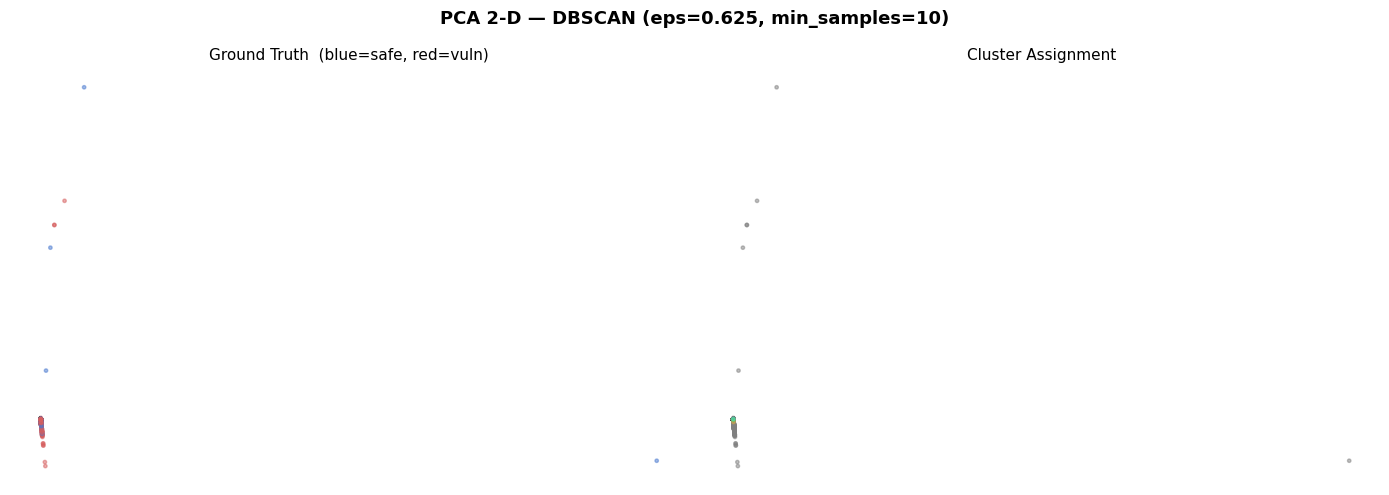

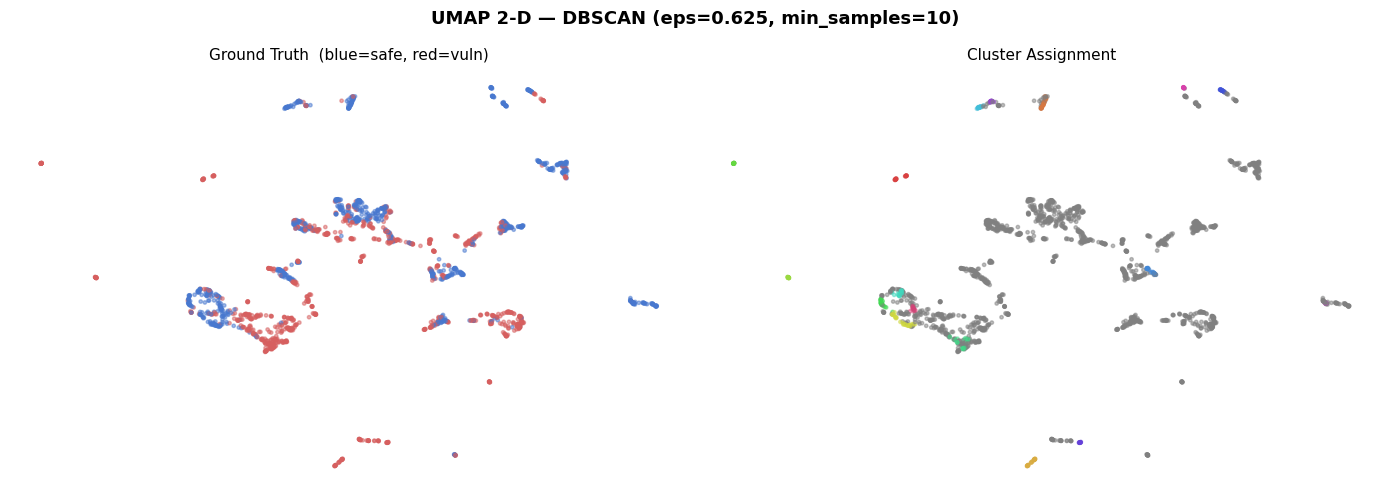

In [18]:
scatter_2d(X_test_pca2, test_labels, db_clusters,
           f'PCA 2-D — DBSCAN (eps={best_eps}, min_samples={best_ms})',
           f'{OUT_DIR}/viz_pca2d_dbscan.png')
scatter_2d(X_test_umap, test_labels, db_clusters,
           f'UMAP 2-D — DBSCAN (eps={best_eps}, min_samples={best_ms})',
           f'{OUT_DIR}/viz_umap2d_dbscan.png')

## Step 5 — Final comparison: Top-K Recall / Precision / F1

In [19]:
km_rec,  km_prec,  km_f1,  km_stats,  km_ntop  = top_k_metrics(km_df, 'cluster', TOP_K_PCT)
db_rec,  db_prec,  db_f1,  db_stats,  db_ntop  = top_k_metrics(db_df, 'cluster', TOP_K_PCT,
                                                                  exclude_noise=True)

summary = pd.DataFrame([
    {'Method': f'K-Means (K={best_k})',
     'n_clusters': best_k, 'n_noise': 0, 'n_top': km_ntop,
     'Recall': round(km_rec, 4), 'Precision': round(km_prec, 4), 'F1': round(km_f1, 4)},
    {'Method': f'DBSCAN (eps={best_eps}, ms={best_ms})',
     'n_clusters': int(best_row['n_clusters']), 'n_noise': n_noise, 'n_top': db_ntop,
     'Recall': round(db_rec, 4), 'Precision': round(db_prec, 4), 'F1': round(db_f1, 4)},
])

display(summary.style.highlight_max(subset=['Recall','Precision','F1'], color='lightgreen'))
summary.to_csv(f'{OUT_DIR}/comparison_summary.csv', index=False)

print('\nK-Means cluster risk scores:')
display(km_stats)
print('\nDBSCAN cluster risk scores (noise excluded):')
display(db_stats)

print(f'\nAll outputs saved to {OUT_DIR}/')

,Method,n_clusters,n_noise,n_top,Recall,Precision,F1
0,K-Means (K=4),4,0,1,0.155700,0.810500,0.261200
1,"DBSCAN (eps=0.625, ms=10)",17,1622,6,0.956900,1.000000,0.978000



K-Means cluster risk scores:


,cluster,n_vulnerable,cluster_size,risk_score
0,3,154,190,0.810526
1,2,3,5,0.600000
2,0,832,1738,0.478711
3,1,0,1,0.000000



DBSCAN cluster risk scores (noise excluded):


,cluster,n_vulnerable,cluster_size,risk_score
0,0,18,18,1.000000
1,7,32,32,1.000000
2,2,21,21,1.000000
3,12,10,10,1.000000
4,4,15,15,1.000000
5,5,15,15,1.000000
6,8,2,16,0.125000
7,6,2,19,0.105263
8,3,1,28,0.035714
9,1,0,32,0.000000



All outputs saved to ../models/lib/eval/


According to the analyzation above, K-means is more suitable for the clustering task.

## The noise problem with DBSCAN

DBSCAN marked 83.9% of the test set (1,622/1,934 packages) as noise. Of those noise points, 873 are actually vulnerable packages that DBSCAN simply refused to classify. The evaluation's exclude_noise=True removes these from the denominator, which inflates the metrics dramatically